# **Desafio Final: Vagas Tech | Ada Lovelace**

## **Etapa 1: Setup e Conexão (Fisicamente)**

In [35]:
import sqlite3

try:
  print("Criando o arquivo físico do banco de dados 'vagas_tech.db'...")

  # Abre a conexão (se o arquivo não existir, o SQLite cria um arquivo .db vazio na raiz)
  conexao = sqlite3.connect('vagas_tech.db')
  print("O banco 'vagas_tech.db' foi criado fisicamente na pasta de arquivos!")

  conexao.close()

except Exception as e:
  print(f"Erro na criação do banco: {e}")

Criando o arquivo físico do banco de dados 'vagas_tech.db'...
O banco 'vagas_tech.db' foi criado fisicamente na pasta de arquivos!


## **Etapa 2: Criação Física do Banco SQL (DDL no DBeaver)**

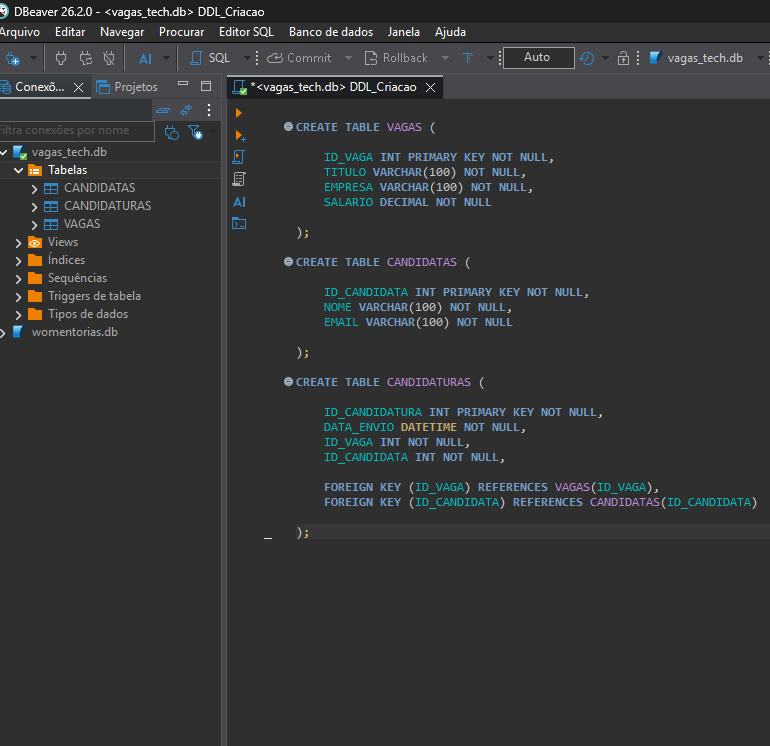

## **Etapa 3: Desenvolvimento do CRUD em C# (ADO.NET)**

### **1. Instalando o .NET SDK na máquina do Colab**

In [3]:
print("Instalando o repositório de pacotes da Microsoft...")
!wget https://packages.microsoft.com/config/ubuntu/22.04/packages-microsoft-prod.deb -O packages-microsoft-prod.deb -q
!dpkg -i packages-microsoft-prod.deb -q
!rm packages-microsoft-prod.deb

print("Instalando o .NET 8 SDK... Por favor, aguarde.")
!apt-get update -y -q > /dev/null
!apt-get install -y dotnet-sdk-8.0 -q > /dev/null

print("\nVerificando a instalação do .NET...")
!dotnet --version


Instalando o repositório de pacotes da Microsoft...
dpkg: error: cannot access archive '-q': No such file or directory
Instalando o .NET 8 SDK... Por favor, aguarde.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)

Verificando a instalação do .NET...
=8.0.131


### **2. Criando o projeto e instalando pacotes de SQL**

In [4]:
print("Criando o novo projeto de console C# 'VagasTechApp'...")
# Cria o projeto na pasta 'VagasTechApp'
!dotnet new console -n VagasTechApp

print("\\nInstalando a biblioteca Microsoft.Data.Sqlite para execução de SQL...")
# Adiciona o driver oficial do SQLite para C# apontando explicitamente para o projeto
!dotnet add VagasTechApp/VagasTechApp.csproj package Microsoft.Data.Sqlite -v 8.0.11

Criando o novo projeto de console C# 'VagasTechApp'...
=========
Welcome to .NET 8.0!
---------------------
SDK Version: 8.0.131

----------------
Installed an ASP.NET Core HTTPS development certificate.
To trust the certificate, view the instructions: https://aka.ms/dotnet-https-linux

----------------
Write your first app: https://aka.ms/dotnet-hello-world
Find out what's new: https://aka.ms/dotnet-whats-new
Explore documentation: https://aka.ms/dotnet-docs
Report issues and find source on GitHub: https://github.com/dotnet/core
Use 'dotnet --help' to see available commands or visit: https://aka.ms/dotnet-cli
--------------------------------------------------------------------------------------
The template "Console App" was created successfully.

Processing post-creation actions...
Restoring /content/VagasTechApp/VagasTechApp.csproj:
  Determining projects to restore...
  Restored /content/VagasTechApp/VagasTechApp.csproj (in 1.07 sec).
Restore succeeded.


\nInstalando a bi

### **3. Métodos CRUD**

In [29]:
%%writefile VagasTechApp/MetodosCRUD.cs
using System;
using Microsoft.Data.Sqlite;

public static class MetodosCRUD
{
  // CREATE: Vaga
  public static void CadastrarVaga (SqliteConnection conexao, int id, string titulo, string empresa, decimal salario)
  {
    var sql = "INSERT INTO VAGAS (ID_VAGA, TITULO, EMPRESA, SALARIO) VALUES (@id, @titulo, @empresa, @salario);";

    using (var comando = new SqliteCommand(sql, conexao))
    {
      comando.Parameters.AddWithValue("@id", id);
      comando.Parameters.AddWithValue("@titulo", titulo);
      comando.Parameters.AddWithValue("@empresa", empresa);
      comando.Parameters.AddWithValue("@salario", salario);

      comando.ExecuteNonQuery();
    }
  }

  // CREATE: Candidata
	public static void CadastrarCandidata (SqliteConnection conexao, int id, string nome, string email)
  {
		var sql = "INSERT INTO CANDIDATAS (ID_CANDIDATA, NOME, EMAIL) VALUES (@id, @nome, @email);";

		using (var comando = new SqliteCommand(sql, conexao))
		{
			comando.Parameters.AddWithValue("@id", id);
			comando.Parameters.AddWithValue("@nome", nome);
			comando.Parameters.AddWithValue("@email", email);

			comando.ExecuteNonQuery();
		}
	}

  // CREATE: Candidatura
  public static void EnviarCandidatura (SqliteConnection conexao, int id, int idVaga, int idCandidata, DateTime dataEnvio)
  {
    var sql = @"INSERT INTO CANDIDATURAS (ID_CANDIDATURA, DATA_ENVIO, ID_VAGA, ID_CANDIDATA) VALUES (@id, @dataEnvio, @idVaga, @idCandidata);";

    using (var comando = new SqliteCommand(sql, conexao))
    {
        comando.Parameters.AddWithValue("@id", id);
        comando.Parameters.AddWithValue("@dataEnvio", dataEnvio.ToString("yyyy-MM-dd HH:mm:ss"));
        comando.Parameters.AddWithValue("@idVaga", idVaga);
        comando.Parameters.AddWithValue("@idCandidata", idCandidata);

        comando.ExecuteNonQuery();
    }
  }

  // READ: Consultar Candidaturas
  public static void ConsultarCandidaturas (SqliteConnection conexao)
  {
	  var sql = @"
    SELECT CANDIDATAS.NOME, CANDIDATAS.EMAIL, VAGAS.TITULO, VAGAS.EMPRESA
    FROM CANDIDATURAS
    INNER JOIN CANDIDATAS ON CANDIDATAS.ID_CANDIDATA = CANDIDATURAS.ID_CANDIDATA
    INNER JOIN VAGAS ON VAGAS.ID_VAGA = CANDIDATURAS.ID_VAGA;";

    using (var comando = new SqliteCommand(sql, conexao))
    {
		  using (var leitor = comando.ExecuteReader())
      {
        Console.WriteLine("\n=============================================================== CANDIDATURAS =============================================================\n");
			  while (leitor.Read())
			  {
          Console.WriteLine($"Nome: {leitor["NOME"]} | Email: {leitor["EMAIL"]} | Vaga: {leitor["TITULO"]} | Empresa: {leitor["EMPRESA"]}");
			  }
        Console.WriteLine("\n==========================================================================================================================================");
      }
    }
  }

  // UPDATE: Atualiza Salário da Vaga
  public static void AtualizarSalarioVaga (SqliteConnection conexao, int idVaga, decimal novoSalario)
  {
	  var sql = "UPDATE VAGAS SET SALARIO = @novoSalario WHERE ID_VAGA = @idVaga;";

    using (var comando = new SqliteCommand(sql, conexao))
    {
	    comando.Parameters.	AddWithValue("@novoSalario", novoSalario);
	    comando.Parameters.AddWithValue("@idVaga", idVaga);

	    comando.ExecuteNonQuery();

    }
  }

  // DELETE: Cancelar Candidatura
    public static void CancelarCandidatura(SqliteConnection conexao, int idCandidatura)
    {
        var sql = "DELETE FROM CANDIDATURAS WHERE ID_CANDIDATURA = @idCandidatura;";
        using (var comando = new SqliteCommand(sql, conexao))
        {
            comando.Parameters.AddWithValue("@idCandidatura", idCandidatura);
            comando.ExecuteNonQuery();
        }
    }
}

Overwriting VagasTechApp/MetodosCRUD.cs


#### **3.1 Compilando o projeto para verificar se há erros de sintaxe**

In [21]:
!dotnet build VagasTechApp

=MSBuild version 17.8.49+7806cbf7b for .NET
  Determining projects to restore...
  All projects are up-to-date for restore.
  VagasTechApp -> /content/VagasTechApp/bin/Debug/net8.0/VagasTechApp.dll

Build succeeded.
    0 Warning(s)
    0 Error(s)

Time Elapsed 00:00:02.00


## **Etapa 4: Simulação e Integração**

### **1. Lógica de integração no arquivo Program.cs**

In [36]:
%%writefile VagasTechApp/Program.cs
using System;
using Microsoft.Data.Sqlite;

class Program
{
  static void Main(string[] args)
  {
    var stringConexao = "Data Source=/content/vagas_tech.db";

    try
    {
      Console.WriteLine("\n==========================================================================================================================================");
      Console.WriteLine("                                                INICIANDO INTEGRAÇÃO DA PLATAFORMA VAGASTECH");
      Console.WriteLine("==========================================================================================================================================\n");

      using (var conexao = new SqliteConnection(stringConexao))
      {
        conexao.Open();
        Console.WriteLine("Conexão estabelecida com o arquivo 'vagas_tech.db'!");

        // CREATE: Vagas
        Console.WriteLine("\n[Etapa 1] Realizando o cadastro das vagas");
        MetodosCRUD.CadastrarVaga(conexao, 1, "Engenheira de Dados", "Alfa", 9000m);
        MetodosCRUD.CadastrarVaga(conexao, 2, "Analista de BI", "Ômega", 7500m);
        Console.WriteLine("As vagas 1 e 2 foram cadastradas com sucesso!");

        // CREATE: Candidata
        Console.WriteLine("\n[Etapa 2] Criando o cadastro das candidatas");
        MetodosCRUD.CadastrarCandidata(conexao, 1, "Mariana Souza", "mariana.souza@gmail.com");
        Console.WriteLine("A candidata 1 foi cadastrada com sucesso!");

        // CREATE: Candidatura
        Console.WriteLine("\n[Etapa 3] Inserindo as candidaturas das candidatas para as vagas");
        MetodosCRUD.EnviarCandidatura(conexao, 901, 1, 1, DateTime.Now);
        MetodosCRUD.EnviarCandidatura(conexao, 902, 2, 1, DateTime.Now);
        Console.WriteLine("As candidaturas 901 e 902 foram realizadas com sucesso!");

        // READ: Consultar Candidaturas
        Console.WriteLine("\n[Etapa 4] Consultando as candidaturas cadastradas");
        MetodosCRUD.ConsultarCandidaturas(conexao);

        // UPDATE: Atualiza Salário da Vaga
        Console.WriteLine("\n[Etapa 5] Atualizando o salário da vaga 1");
        MetodosCRUD.AtualizarSalarioVaga(conexao, 1, 9500m);
        Console.WriteLine("O salário da vaga 1 foi atualizado com sucesso!");

        // DELETE: Cancelar Candidatura
        Console.WriteLine("\n[Etapa 6] Cancelando a candidatura 902");
        MetodosCRUD.CancelarCandidatura(conexao, 902);
        Console.WriteLine("A candidatura 902 foi cancelada com sucesso!");

        // READ: Consultar Candidaturas
        Console.WriteLine("\n[Etapa 7] Consultando candidaturas para confirmar cancelamento");
        MetodosCRUD.ConsultarCandidaturas(conexao);

        conexao.Close();
      }
    }
    catch (Exception ex)
    {
      Console.WriteLine($"Erro na integração: {ex.Message}");
    }
    finally
    {
      Console.WriteLine("\n==========================================================================================================================================");
      Console.WriteLine("                                                           INTEGRAÇÃO FINALIZADA");
      Console.WriteLine("==========================================================================================================================================\n");

    }
  }
}

Overwriting VagasTechApp/Program.cs


#### **1.1 Compilando e executando o projeto de integração**

In [37]:
!dotnet run --project VagasTechApp

==
                                                INICIANDO INTEGRAÇÃO DA PLATAFORMA VAGASTECH

Conexão estabelecida com o arquivo 'vagas_tech.db'!

[Etapa 1] Realizando o cadastro das vagas
As vagas 1 e 2 foram cadastradas com sucesso!

[Etapa 2] Criando o cadastro das candidatas
A candidata 1 foi cadastrada com sucesso!

[Etapa 3] Inserindo as candidaturas das candidatas para as vagas
As candidaturas 901 e 902 foram realizadas com sucesso!

[Etapa 4] Consultando as candidaturas cadastradas

=============================================================== CANDIDATURAS =============================================================

Nome: Mariana Souza | Email: mariana.souza@gmail.com | Vaga: Engenheira de Dados | Empresa: Alfa
Nome: Mariana Souza | Email: mariana.souza@gmail.com | Vaga: Analista de BI | Empresa: Ômega


[Etapa 5] Atualizando o salário da vaga 1
O salário da vaga 1 foi atualizado com sucesso!

[Etapa 6] Cancelando a candidatura 902
A candidatura 902 foi cancelada com s

## **Etapa 5: Validação Final no DBeaver**

### **1. Dados das tabelas persistidos**

#### **1.1 Tabela de vagas**

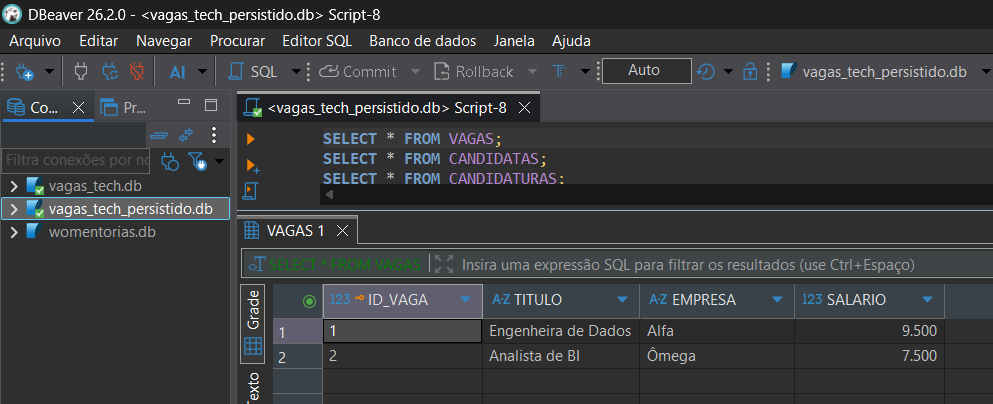

#### **1.2 Tabela de candidatas**

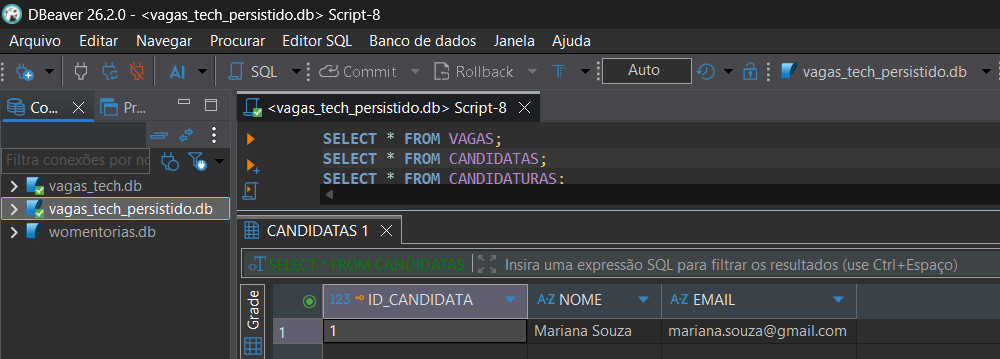

#### **1.3 Tabela de candidaturas**

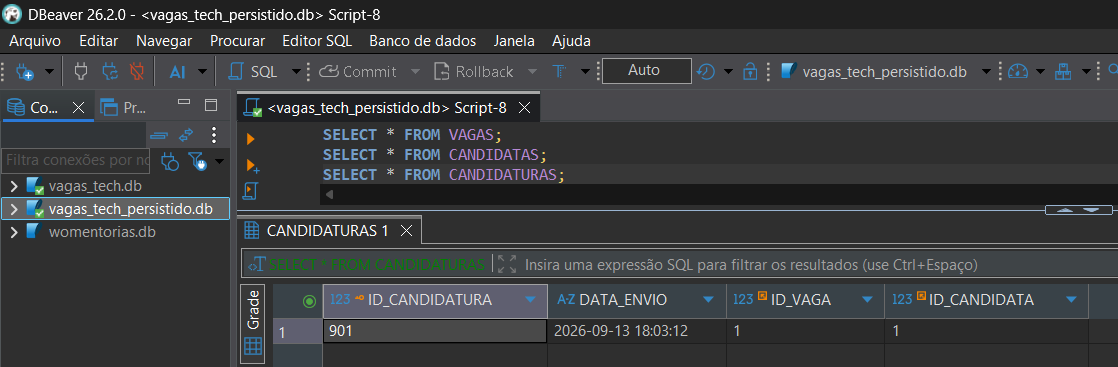